# **랭체인 Multi-modal RAG 구현 [옵션 3]**


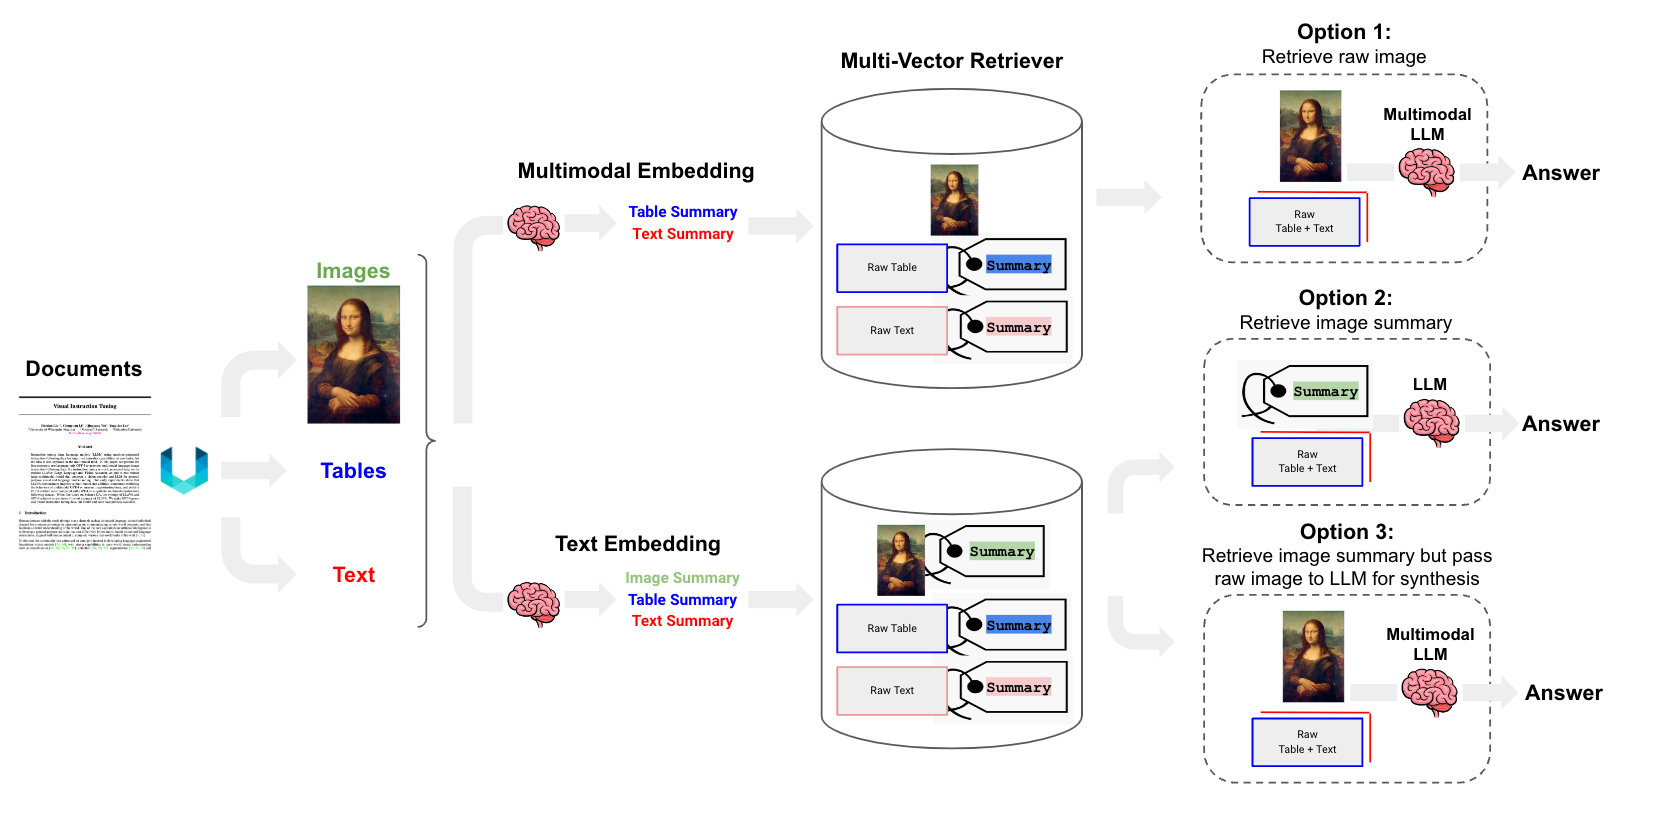

- 이미지 출처: https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb

**3가지 옵션 비교:**

| 옵션 | 임베딩 방식 | 벡터 DB 저장 | 답변 생성 LLM | 이미지 활용 | 장점 | 단점 |
|---|---|---|---|---|---|---|
| 1 | 멀티모달 (CLIP) | 이미지 임베딩, 텍스트 임베딩 | Multimodal | 직접 활용 (base64) | 최고 이미지 활용도, 높은 답변 품질 | 높은 비용, base64 오버헤드 |
| 2 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약) | Text-only | 텍스트 요약 간접 활용 | 비용 효율성, 텍스트 RAG 인프라 활용 | 이미지 정보 손실, 답변 품질 제한적 |
| 3 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약 + 참조) | Multimodal | 원본 이미지 참조 활용 | 옵션 1과 2의 절충, 이미지 정보 손실 감소, 유연성 | 옵션 1보다 이미지 활용도 낮음, 이미지 참조 관리 필요 |

**선택 가이드:**

* **최고 품질 답변:** 옵션 1 (비용 고려)
* **비용 효율성 우선:** 옵션 2 (답변 품질 제한 감수)
* **품질과 효율성 균형:** 옵션 3

---

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

`(3) langfuase handler 설정`

In [3]:
from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

`(4) 유틸리티 함수`

In [4]:
import base64
import io
from io import BytesIO

import numpy as np
from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document

import pickle
from langchain_core.stores import InMemoryStore


def is_base64(s):
    """문자열이 Base64로 인코딩되었는지 확인합니다"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False


def split_image_text_types(docs):
    """numpy 배열 이미지와 텍스트를 분리합니다"""
    images = []
    text = []
    for doc in docs:
        if isinstance(doc, str):
            pass
        elif isinstance(doc, Document):
            doc = doc.page_content  # 문서 내용 추출
        else:
            doc = doc.text # 문서 내용 추출

        if is_base64(doc):
            images.append(doc)  # base64로 인코딩된 문자열
        else:
            text.append(doc)
    return {"images": images, "texts": text}


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 이미지를 주피터 노트북에 표시
    
    매개변수:
    img_base64 (str): Base64로 인코딩된 이미지 문자열
    """
    # Base64 문자열을 소스로 하는 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))

---

## **증권사 분석보고서 문서 로드**

- PDF 문서에서 이미지, 텍스트, 테이블 분리


### 1. **데이터 로딩 및 파싱** 

- 메모리 부족할 경우 별도의 실습파일을 활용 

In [5]:
# 데이터 저장 폴더 경로
data_path = "data/analyst_reports/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

PDF files:
['data/analyst_reports\\20240524_company_234017000.pdf',
 'data/analyst_reports\\20240531_company_652771000.pdf',
 'data/analyst_reports\\20240531_company_753270000.pdf']


In [6]:
from unstructured.partition.pdf import partition_pdf
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    group_broken_paragraphs
)

# PDF 파일을 로드하고 파티셔닝
pdf_chunks = []
for pdf_file in pdf_files:
    chunks = partition_pdf(
        filename=pdf_file,
        strategy="hi_res",              
        infer_table_structure=True,    
        languages=["eng", "kor"],           
        
        # 이미지 추출 설정     
        extract_image_block_types=["Image", "Table"],
        # extract_image_block_output_dir=image_output_dir,   # 이미지 저장 경로
        extract_image_block_to_payload=True, # base64로 저장

        # 후처리 설정
        post_processors=[
            group_broken_paragraphs,
            clean_extra_whitespace,
            ], 

        # 문서 청킹 설정
        chunking_strategy="by_title",
        max_characters=1200,   
        new_after_n_chars=800,
        combine_text_under_n_chars=600,    

    )
    pdf_chunks.extend(chunks)


# 청크 개수 확인
print(len(pdf_chunks))

W1202 13:18:14.350000 8164 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


33


In [7]:
# 타입별 분석
chunk_types = {}
for chunk in pdf_chunks:
    chunk_type = str(type(chunk))
    if chunk_type in chunk_types:
        chunk_types[chunk_type] += 1
    else:
        chunk_types[chunk_type] = 1

print("📋 청크 타입 분포:")
for chunk_type, count in chunk_types.items():
    print(f"  • {chunk_type.split('.')[-1].replace('>', '')}: {count}개")

📋 청크 타입 분포:
  • CompositeElement': 27개
  • TableChunk': 6개


In [8]:
# 청크 내용 확인
for chunk in pdf_chunks[1:3]:
    print(chunk)
    print("=" * 100)

주가(원,5/23)

183,500

시가총액(십억원) 39,818 발행주식수 216,993천주 52주 최고가 241,000원 최저가 131,000원 52주 일간 Beta 60일 일평균거래대금 1,172억원 외국인 지분율 23.9% 배당수익률(2024F) 0.3% 주주구성 셀트리온홀딩스 (외 86인) 28.3% 국민연금공단 (외 1인) 5.3% 자사주 (외 1인) 4.8% 주가상승(%) 1M 6M 12M 상대기준 -1.7 -2.1 절대기준 2.1 6.1 현재 직전 변동 투자의견 BUY BUY - 목표주가 250,000 250,000 - 영업이익(24) 569 569 -

2,284 2,176 3,499 4,671

569 1,806

577 1,808

464 1,452

3,676 2,432 2,104 6,592

0.93

-13.5 213.2

27.8

8.1

2.2

19.5

자료: 유진투자증권

주: 2023년 12월 28일 셀트리온이 셀트리온 헬스케어를 흡수합병함에 따라 2022~2023년 실적과 2024~2025년 예상 실적의 연속성은 없음

250,000 5 200,000. - 150,000 | 100,000 - ” — #7 (4,24) 30,000 7 000 <058 지 수 대 비 ( 우 , p) 20 ' 8 23.5 23.9 24.1 24.5

-3.8

2.2

영업이익(25)

1,806

1,806

-

O12

98

개

자

셀트리온
제 3 성장기: Business Model Innovation 진행 중

기존 의견: 상반기 당사는 2024 년 3 월 4 일 발간한 셀트리온 기업분석 보고서에서 2024 년 상반 에는 보수적 접근 기에는 공격적인 매수 전략보다 보수적 접근 전략이 유효할 것으로 전망하였다. 이는 2023 년 12 월 합병 이후 신제품 출시와 합병 이후 원가율 정상화에 따른 실적 고성장 추이가 하반기부터 본격화될 것으로 판단하여 매출 성장을 확인하 고 접근하는 보수적인 접근을 권유한 것이었다.

신규 의견: 그러

In [9]:
# 청크 저장
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "wb") as f:
    pickle.dump(pdf_chunks, f)

In [10]:
# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "rb") as f: 
    pdf_chunks = pickle.load(f)

# 청크 개수 확인
print(len(pdf_chunks))

33


### 2. **타입별 구조 확인** 

In [11]:
# 각 청크 문서의 타입 확인
set([str(type(el)) for el in pdf_chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.TableChunk'>"}

In [12]:
# CompositeElement 확인
pdf_chunks[1]

In [13]:
# CompositeElement는 하위 구성 요소를 포함하고 있음
pdf_chunks[1].metadata.orig_elements

In [14]:
# Table 객체 확인 
tab = pdf_chunks[1].metadata.orig_elements[2] 
tab.to_dict()

{'type': 'Table',
 'element_id': '5b539d01-f2c3-415a-91af-0ce618bc1190',
 'text': '시가총액(십억원) 39,818 발행주식수 216,993천주 52주 최고가 241,000원 최저가 131,000원 52주 일간 Beta 60일 일평균거래대금 1,172억원 외국인 지분율 23.9% 배당수익률(2024F) 0.3% 주주구성 셀트리온홀딩스 (외 86인) 28.3% 국민연금공단 (외 1인) 5.3% 자사주 (외 1인) 4.8% 주가상승(%) 1M 6M 12M 상대기준 -1.7 -2.1 절대기준 2.1 6.1 현재 직전 변동 투자의견 BUY BUY - 목표주가 250,000 250,000 - 영업이익(24) 569 569 -',
 'metadata': {'detection_class_prob': 0.8288782835006714,
  'coordinates': {'points': ((131.28814697265625, 1378.218505859375),
    (131.28814697265625, 2240.499267578125),
    (733.9306030273438, 2240.499267578125),
    (733.9306030273438, 1378.218505859375)),
   'system': 'PixelSpace',
   'layout_width': 1654,
   'layout_height': 2339},
  'last_modified': '2025-11-16T14:35:12',
  'text_as_html': '<table><tbody><tr><td>시 가 총 액 (십억원)</td><td></td><td>39,818</td></tr><tr><td colspan="3">216,993</td></tr><tr><td></td><td></td><td>241,000% 131,0008</td></tr><tr><td></td><td></td><td>0.93</td></tr><tr><td>60 일 

In [15]:
# Table 객체의 데이터프레임 변환
tab_df = pd.read_html(tab.metadata.text_as_html)[0] 

# 데이터프레임 확인
tab_df

,0,1,2
0,시 가 총 액 (십억원),NaN,39818
1,216993,216993,216993
2,NaN,NaN,"241,000% 131,0008"
3,NaN,NaN,0.93
4,60 일 일 평 균 거 래 대금,NaN,117244
5,외국인 지분율,NaN,23.9%
6,배 당 수 익 률 (2024),NaN,0.3%
7,외 %) Ole 주 가 상,6M,12M
8,FN 상 다 7,2.1,NaN
9,FN 7,61,22


In [16]:
# 데이터프레임을 마크다운 변환
tab_md = tab_df.to_markdown(index=False)
print(tab_md)

| 0                         | 1       | 2                 |
|:--------------------------|:--------|:------------------|
| 시 가 총 액 (십억원)      | nan     | 39818             |
| 216993                    | 216993  | 216993            |
| nan                       | nan     | 241,000% 131,0008 |
| nan                       | nan     | 0.93              |
| 60 일 일 평 균 거 래 대금 | nan     | 117244            |
| 외국인 지분율             | nan     | 23.9%             |
| 배 당 수 익 률 (2024)     | nan     | 0.3%              |
| 외 %) Ole 주 가 상        | 6M      | 12M               |
| FN 상 다 7                | 2.1     | nan               |
| FN 7                      | 61      | 22                |
| nan                       | 직전    | nan               |
| 투 자 의견                | BUY     | -                 |
| 목 표 주가 250,000        | 250000  | -                 |
| 영 업 이 익 (24)          | 569     | -                 |
| 연어 1601/32              | 41 QNnK | .                 |



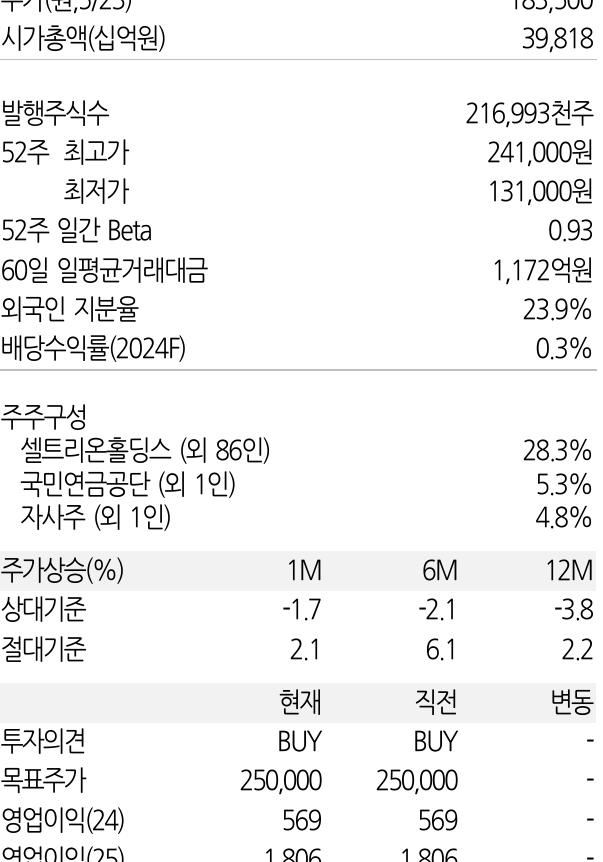

In [17]:
# image_base64 이미지 확인
plt_img_base64(tab.metadata.image_base64)

In [18]:
# TableChunk 객체 확인
for i, c in enumerate(pdf_chunks):
    if "TableChunk" in str(type(c)):
        print(f"TableChunk {i}:")
        print(c)
        print("=" * 100)

TableChunk 8:
손 익 계산서 ( 단 위 : 십 억원) 20224 2023A 2024F 2025F 2026F 매출액 2284 2176 3499 _ 4671 _ 4972 증 가 율 (%) 206 (07) 608 335 64 매출원가 1251 _ 1125 _ 1752 _ 1449 _ 1442 매 출 총 이익 1033 1,052 1747 _ 3222 3530 판매 및 일 반 관리비 385 400 _ 1178 _ 1416 _ 1608 기 타 영 업 손익 12 4 194 20 14 영 업 이익 6497 651 569 1806 1923 증 가 율 (%) (130) 07 (127) 2174 65 EBITDA 874 897 771 2103 _ 2283 증 가 율 (%) 688 27 041 1728 85 영 업 외 손 익 (21) 20 8 2 (6) 이 자 수익 14 19 19 19 19 이 자 비용 8 10 14 14 14 지 분 법 손익 7 (13) 0 0 0 기 영 업 손익 (35) B 3 @ (10 타 세 전 순이익 626 671 577 1808 = 1918 증 가 율 (%) 052 72 040 2133 61 법 인 세 95 131 113 356 391 비용 당 기 순이익 543 540 464 1452 1527 증 가 율 (%) 69 (05 (141) 2132 52 지 배 주 주 지분 538 536 464 1452 1527 증 가 율 (%) 02) 04 035 2132 52 배 비 지 지 분 5 4 0 0 0 태 원 5( ) 3676 2432 2104 6592 6,932 증 가 (%) 03) 639 035) _ 2132 52 율 수 정 505( 원 ) 3676 2432 2104 6592 _ 6932 증 가 율 (%) 03) 639 035) _ 2132 52 주 요 투 자 지표 20224 2023A 2024F 2025F 2026F 주 당 지 표 (원) EPS 3676 2432 2104 6592 6,932 BPS 29398 77,083 78478 84570 91,

In [19]:
# TableChunk 객체 확인
pdf_chunks[4].metadata.orig_elements

In [20]:
# TableChunk에서 Table 객체 확인
# pdf_chunks[4]는 CompositeElement이므로 TableChunk인 pdf_chunks[8] 사용
tab = pdf_chunks[8].metadata.orig_elements[0]

# Table 객체 확인
tab.to_dict()

{'type': 'Table',
 'element_id': '39ffaa28-2dc0-4fbe-bf51-5f104b72829d',
 'text': '(단위:십억원) 증가율(%) 판매 및 일반관리비 기타영업손익 증가율(%) EBITDA 증가율(%) 이자수익 이자비용 지분법손익 기타영업손익 증가율(%) 증가율(%) 지배주주지분 증가율(%) 비지배지분 EPS(원) 증가율(%) 증가율(%) 주요투자지표 EPS BPS DPS PER PBR EV/ EBITDA 배당수익률 PCR 영업이익률 EBITDA이익률 순이익률 ROE ROIC 순차입금/자기자본 유동비율 이자보상배율 총자산회전율 매출채권회전율 2022A 2023A 2024F 2025F 2026F 2,284 2,176 3,499 4,671 4,972 20.6 (4.7) 60.8 33.5 6.4 1,251 1,125 1,752 1,449 1,442 1,033 1,052 1,747 3,222 3,530 385 400 1,178 1,416 1,608 12 4 194 20 14 647 651 569 1,806 1,923 (13.0) 0.7 (12.7) 217.4 6.5 874 897 771 2,103 2,283 (8.8) 2.7 (14.1) 172.8 8.5 (21) 20 8 2 (5) 14 19 19 19 19 8 10 14 14 14 7 (13) 0 0 0 (35) 23 3 (4) (10) 626 671 577 1,808 1,918 (15.2) 7.2 (14.0) 213.3 6.1 95 131 113 356 391 543 540 464 1,452 1,527 (8.9) (0.5) (14.1) 213.2 5.2 538 536 464 1,452 1,527 (7.2) (0.4) (13.5) 213.2 5.2 5 4 0 0 0 3,676 2,432 2,104 6,592 6,932 (7.3) (33.9) (13.5) 213.2 5.2 3,676 2,432 2,104 6,592 6,932 (7.3) (33.9) (13.5) 213.2 

In [21]:
# Table 객체의 데이터프레임 변환
# TableChunk의 첫 번째 Table 요소 사용
table_df = pdf_chunks[8].metadata.orig_elements[0].metadata.text_as_html
table_df = pd.read_html(table_df)[0]  # 첫 번째 테이블

# 데이터프레임 확인
table_df

,손 익 계산서,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,( 단 위 : 십 억원),20224,2023A,2024F,2025F,2026F
1,매출액,2284,2176,3499,_ 4671,_ 4972
2,증 가 율 (%),206,(07),608,335,64
3,매출원가,1251,_ 1125,_ 1752,_ 1449,_ 1442
4,매 출 총 이익,1033,1052,1747,_ 3222,3530
5,판매 및 일 반 관리비,385,400,_ 1178,_ 1416,_ 1608
6,기 타 영 업 손익,12,4,194,20,14
7,영 업 이익,6497,651,569,1806,1923
8,증 가 율 (%),(130),07,(127),2174,65
9,EBITDA,874,897,771,2103,_ 2283


---

## **[옵션 3]** 멀티모달 LLM으로 이미지 + 요약 활용해서 생성 

- **멀티모달 LLM** 모델(GPT4-V, LLaVA 등)을 사용하여 이미지에서 **텍스트 요약**을 생성
- 생성된 텍스트를 **임베딩**하고 필요할 때 **검색**
- 검색 시 텍스트 청크와 함께 **원본 이미지**를 가져옴
- 최종 답변 생성 단계에서 **멀티모달 LLM**에 텍스트와 원본 이미지를 함께 전달

`(1) 타입별 구분`

In [22]:
# 타입별 분류
tables = []
texts = []
images = []

for chunk in pdf_chunks:
    # 테이블 청크
    if "Table" in str(type(chunk)):
        tables.append(chunk)
    
    # 텍스트 청크 (CompositeElement)
    elif "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

# 이미지 추출 (metadata에서)
for chunk in pdf_chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for el in chunk.metadata.orig_elements:
            # 이미지 요소가 있는 경우만 추출
            if hasattr(el.metadata, 'image_base64') and el.metadata.image_base64:
                images.append(el.metadata.image_base64)

print(f"📊 테이블 청크: {len(tables)}개")
print(f"📝 텍스트 청크: {len(texts)}개")
print(f"🖼️ 이미지: {len(images)}개")

📊 테이블 청크: 6개
📝 텍스트 청크: 27개
🖼️ 이미지: 42개


In [23]:
# 테이블 청크 확인
tables[0]

In [24]:
# 텍스트 청크 확인
texts[0]


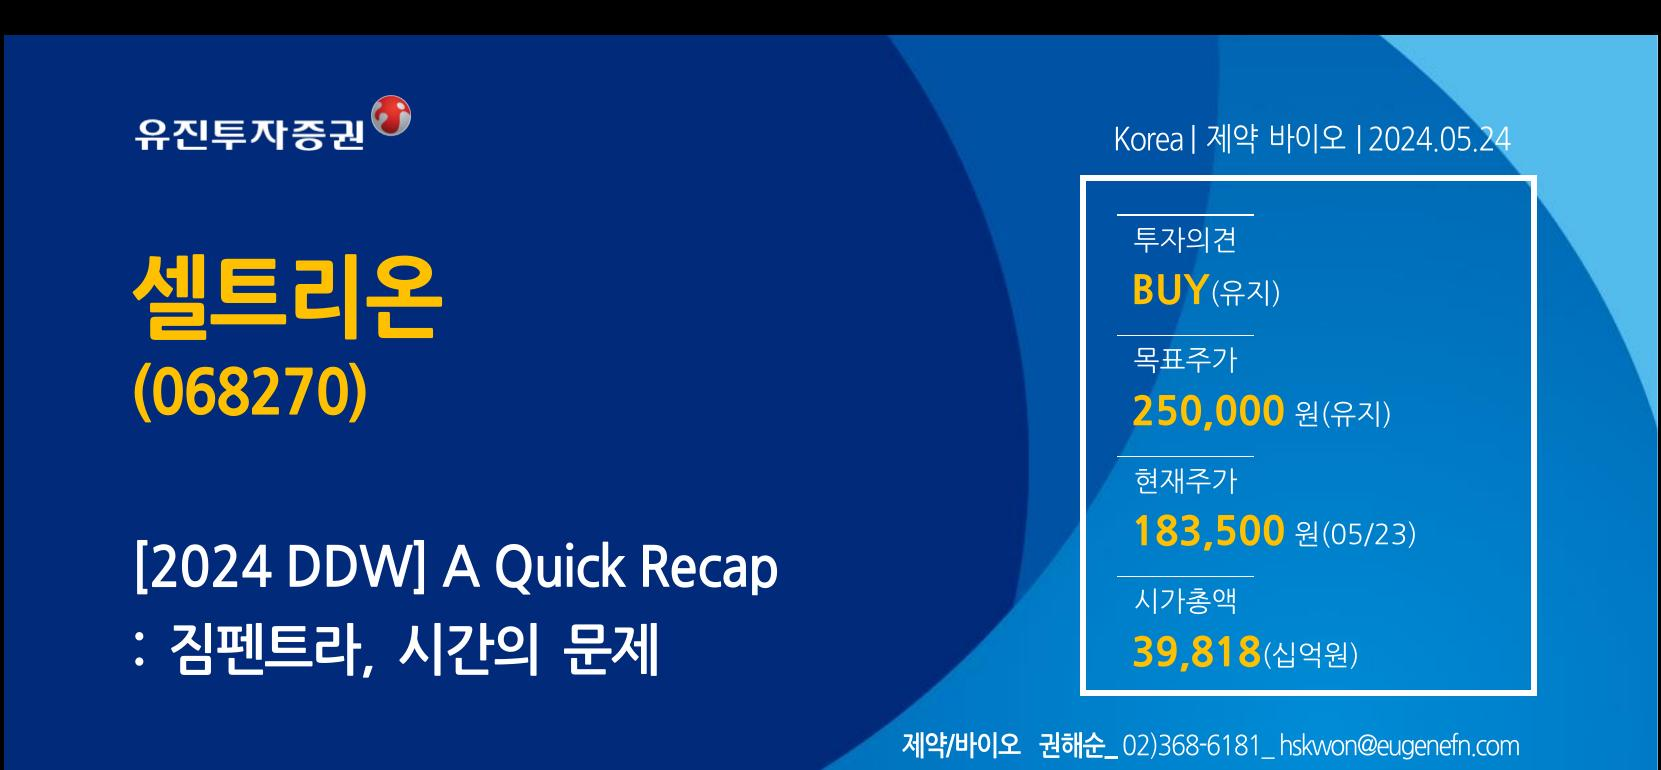

In [25]:
# 이미지 청크 확인
plt_img_base64(images[0])

`(2) 이미지, 표 요약`

In [26]:
# Part2에서 요약한 결과를 로드
output_dir = "data/analyst_reports/summaries"
os.makedirs(output_dir, exist_ok=True)

# 요약된 텍스트 로드
with open(os.path.join(output_dir, "summaries.json"), "r", encoding="utf-8") as f:
    summary_data = json.load(f)

text_summaries = summary_data.get("text_summaries", [])
table_summaries = summary_data.get("table_summaries", [])
image_summaries = summary_data.get("image_summaries", [])

print(f"📄 텍스트 요약: {len(text_summaries)}개")
print(f"📊 표 요약: {len(table_summaries)}개")
print(f"🖼️ 이미지 요약: {len(image_summaries)}개"   )

📄 텍스트 요약: 27개
📊 표 요약: 6개
🖼️ 이미지 요약: 42개


`(3) 벡터스토어에 저장`

In [27]:
from langchain_core.stores import InMemoryStore
import pickle

def save_store_to_disk(store: InMemoryStore, path: str):
    """InMemoryStore를 디스크에 저장"""
    data = dict(store.store)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"💾 Store 저장: {path}")


def load_store_from_disk(path: str):
    """디스크에서 InMemoryStore 로드"""
    with open(path, 'rb') as f:
        data = pickle.load(f)
    new_store = InMemoryStore()
    new_store.store = data
    return new_store

In [28]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

# 자식 청크를 인덱싱하기 위한 벡터 저장소
vectorstore = Chroma(
    collection_name="mm_summaries_base64", 
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./legal_chroma_db",  # 벡터 저장소 경로
)

# 부모 문서를 위한 저장 레이어
store = InMemoryStore()
id_key = "doc_id"

# 검색기 생성
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

In [29]:
# retriever.vectorstore.delete_collection()  # 기존 컬렉션 삭제

In [30]:
### 텍스트 추가 ###

# 각 텍스트에 대한 고유 ID 생성
doc_ids = [str(uuid.uuid4()) for _ in texts]  

# 텍스트 요약 문서 생성
summary_texts = [
    Document(page_content=s, metadata={id_key: doc_ids[i], "source": "text"})
    for i, s in enumerate(text_summaries)
]

# 원본 텍스트 문서 생성
original_texts = [
    Document(page_content=t.text, metadata={id_key: doc_ids[i], "source": "text"})
    for i, t in enumerate(texts)
]

# 벡터 저장소에 텍스트 요약 추가
retriever.vectorstore.add_documents(summary_texts)  

# 문서 저장소에 원본 텍스트 추가
retriever.docstore.mset(list(zip(doc_ids, original_texts)))  

print(f"📄 텍스트 요약 추가: {len(summary_texts)}개")

📄 텍스트 요약 추가: 27개


In [31]:
# 검색 테스트
query = "2023년 2분기 매출은 얼마인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: af7e812d-d58a-4193-802e-ae5667a392b8
Source: text
Content: 581 영업이익

1,375

2,902

2,554 영업외손익

634

1,703

217

348

107 세전순이익

240

4,274 17,126 17,433 18,775 20,192 법인세비용

4,139 16,981 17,288 18,630 20,047 당기순이익

220

7,082

(2,046)

145

1,810 수정EPS(원)

2...
ID: a7dccbfa-6769-4832-be10-b6789f288f5c
Source: text
Content: Korea | 전기∙전자 | 2024.05.31 투자의견 삼성전기 BUY(유지) 목표주가 (009150) 200,000 원(상향) 현재주가 156,600 원(5/30) 시가총액 좋아질 일만 남았다 11,697(십억원) 이승우_swlee6591@ / 임소정_sophie.yim@

Korea | 전기∙전자 | 2024.05.31

1분기 실적은 매출 2조 6,...
ID: b9b6ef9e-e7e5-4161-94df-1b244f9cda62
Source: text
Content: 1,863 1,151 1,840 1,818 2,386

2,985 3,218 11,796 7,773 5,296

526

(477) 밸류에이션(배,%)

(834)

(794)

1,190 5,901 1,252 1,142

8

(3,228) (5,290) (4,260) (6,076) (6,412)

(2) 수익성(%)

101 (1,238) (1,038)...
ID: d5db06e2-347f-44da-8a1c-7ef0047266f3
Source: text
Content: 손익계산서

대차대조표

(단위:십억원) 자산총계 유동자산 현금성자산 매출채권 재고자산 비유동자산 투자자산 유형자산 기타 부채총계 유동부채 매입채무 유동성이자부채 기타 비유동부채 비유동이자부채 기타 자본총계 지배지분 

In [32]:
### 테이블 요약 추가 ###

# 각 테이블에 대한 고유 ID 생성
table_ids = [str(uuid.uuid4()) for _ in table_summaries]  

# 테이블 요약 문서 생성
summary_tables = [
    Document(page_content=s, metadata={id_key: table_ids[i], "source": "table"})
    for i, s in enumerate(table_summaries)
]

# 원본 테이블 문서 생성 (metadata에서 HTML 추출)
original_tables = [
    Document(page_content=t.metadata.orig_elements[0].metadata.text_as_html, metadata={id_key: table_ids[i], "source": "table"})
    for i, t in enumerate(tables)
]

# 벡터 저장소에 테이블 요약 추가
retriever.vectorstore.add_documents(summary_tables)  

# 문서 저장소에 원본 테이블 추가
retriever.docstore.mset(list(zip(table_ids, original_tables)))  

print(f"📄 테이블 요약 추가: {len(summary_tables)}개")

📄 테이블 요약 추가: 6개


In [33]:
# 검색 테스트
query = "2023년 2분기 매출은 얼마인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: d66c755a-bb33-46a7-86e9-61143eab7707
Source: table
Content: <table><thead><tr><th>손 익 계산서</th><th></th><th></th><th></th><th></th><th></th></tr></thead><tbody><tr><td>( 단 위 : 십 억원)</td><td>20224</td><td>2023A</td><td>2024F</td><td>2025F</td><td>2026F</td></tr>...
ID: 1342d1a7-564d-467c-94f6-008253d4eac0
Source: table
Content: <table><thead><tr><th>익 ( 단 위 : 십 억원)</th><th>20224</th><th>20234</th><th>20245</th><th>202 다</th><th>0 202</th></tr></thead><tbody><tr><td>매출액</td><td>83,467</td><td>84,228</td><td>87,259</td><td>92,...
ID: af7e812d-d58a-4193-802e-ae5667a392b8
Source: text
Content: 581 영업이익

1,375

2,902

2,554 영업외손익

634

1,703

217

348

107 세전순이익

240

4,274 17,126 17,433 18,775 20,192 법인세비용

4,139 16,981 17,288 18,630 20,047 당기순이익

220

7,082

(2,046)

145

1,810 수정EPS(원)

2...
ID: a7dccbfa-6769-4832-be10-b6789f288f5c
Source: text
Content: Korea | 전기∙전자 | 2024.05.31 투자의견 삼성전기 BUY(유지) 목표주가 (009150) 200,000 원(상향) 현재주가 156,600 원(5/30) 시가총액 좋아질 일만 남았다 11,697(십억

In [34]:
# 이미지 추가
img_ids = [str(uuid.uuid4()) for _ in image_summaries]  # 각 이미지 요약에 대한 고유 ID 생성

# 이미지 요약 문서 생성
summary_images = [
    Document(page_content=s, metadata={id_key: img_ids[i], "source": "image"})  # 각 이미지 요약을 Document 객체로 변환
    for i, s in enumerate(image_summaries)
]

# 원본 이미지 문서 생성
original_images = [
    Document(page_content=img, metadata={id_key: img_ids[i], "source": "image"})  # 각 원본 이미지를 Document 객체로 변환
    for i, img in enumerate(images)
]

# 벡터 저장소에 이미지 요약 추가
retriever.vectorstore.add_documents(summary_images)  

# 문서 저장소에 원본 이미지 추가
retriever.docstore.mset(
    list(
        zip(
            img_ids, original_images  # 이미지 ID와 원본 이미지를 쌍으로 저장
        )
    )
)  # 문서 저장소에 이미지 ID 추가하여 검색 가능하게 함


In [35]:
# 검색 테스트
query = "삼성전기의 과거 2년간 투자 의견은 무엇인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: 24cf9d08-4df0-4950-809d-8c015fdba8c1
Source: image
Content: /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIy...
ID: 1a1883a2-4f21-404a-b1e6-a88caac9b417
Source: text
Content: 삼성전기(009150.KS) 재무제표...
ID: d2d2729f-2d50-40eb-8ac9-900df682625f
Source: text
Content: 투자기간 및 투자등급/투자의견 비율

종목추천 및 업종추천 투자기간: 12개월 (추천기준일 종가대비 추천종목의 예상 목표수익률을 의미함) 당사 투자의견 비율(%) ㆍSTRONG BUY(매수) 추천기준일 종가대비 +50%이상 1% ㆍBUY(매수) 추천기준일 종가대비 +15%이상 ~ +50%미만 93% ㆍHOLD(중립) 추천기준일 종가대비 -10%이상 ∼ +1...
ID: a7dccbfa-6769-4832-be10-b6789f288f5c
Source: text
Content: Korea | 전기∙전자 | 2024.05.31 투자의견 삼성전기 BUY(유지) 목표주가 (009150) 200,000 원(상향) 현재주가 156,600 원(5/30) 시가총액 좋아질 일만 남았다 11,697(십억원) 이승우_swlee6591@ / 임소정_sophie.yim@

Korea | 전기∙전자 | 2024.05.31

1분기 실적은 매출 2조 6,...


In [36]:
# store 저장
save_store_to_disk(store, "mm_summaries_base64.pkl") 

💾 Store 저장: mm_summaries_base64.pkl


In [37]:
# store 로드
loaded_store = load_store_from_disk("mm_summaries_base64.pkl")

# 벡터 저장소 로드
vectorstore = Chroma(
    collection_name="mm_summaries_base64", 
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./legal_chroma_db",  # 벡터 저장소 경로
)

# 로드한 저장소로 새 검색기 만들기
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,  
    docstore=loaded_store,
    id_key=id_key,
)

In [38]:
# 벡터 스토어에서 문서 검색 
docs = retriever.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")
print(f"검색된 문서 개수: {len(docs)}")

for doc in docs:
    print(doc)
    print("=" * 100)

검색된 문서 개수: 4
page_content='Korea | 전기∙전자 | 2024.05.31 투자의견 삼성전기 BUY(유지) 목표주가 (009150) 200,000 원(상향) 현재주가 156,600 원(5/30) 시가총액 좋아질 일만 남았다 11,697(십억원) 이승우_swlee6591@ / 임소정_sophie.yim@

Korea | 전기∙전자 | 2024.05.31

1분기 실적은 매출 2조 6,243억원, 영업이익 1,803억원으로 각각 전년비 30%, 29% 증가. ①컴포넌트사업부는 부진한 세트 수요에도 불구하고 AI 관련 산업용 제품과 전장용 제품 매출 비중 증가에 따른 제품 믹스 개선으로 출 하량 감소에도 전기비 5% 증가한 매출 실현. ②광학통신솔루션사업부는 국내 전략 거래선의 전작 대비 약 한 달 이른 플래그쉽 모델 출시로 인해 고부가제품 중심의 믹스 개선 실현. 지속 견조한 전장용 카메라 출하와 중화 거래 선향 고사양 제품 양산 본격화에 힘입어 전기비 32% 증가한 매출 실현. ③패키지솔루션사업부는 일부 최종시장의 수요 부진으로 인해 전기비 3% 감소한 매출 실현.

2024년 실적은 매출 10조 1,212억원, 영업이익 8,779억원 예상. ①컴포넌트사업부는 AI와 전장 위주의 제품 믹스 개선 지속 및 낮아진 재고 수준에서 완만한 회복이 이루어질 것으로 전망. ②광학통신솔루션사업부는 플래그쉽 스 마트폰 신제품 출시 모멘텀은 줄어들겠으나, 3분기부터 하반기 신제품 출시 효과 반영될 것. ③패키지솔루션사업부 는 범용 서버 교체 수요 증가와 AI PC 출시 및 Windows 10 지원 종료에 따른 기업 위주 PC 교체 주기 도래에 따 라 하반기 회복세를 전망.

‘25년 예상 BPS 기준 Target P/B 1.9배를 적용해 목표가를 20만원으로 상향하고 투자의견 ‘BUY’ 유지.

2023A 2024E 2025E 2026E 12월 결산(십억원) 매출액 영업이익 639 세전손익 543 당기순이익 450 713 EPS(원) 증감률(%) -56.9

In [39]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from base64 import b64decode


def process_prompt(kwargs):
    """문맥과 질문을 기반으로 프롬프트를 구성합니다"""
    # 검색된 문서(텍스트와 이미지)와 사용자 질문 추출
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    print(f"검색된 문서 개수: {len(docs_by_type['texts'])}")
    print(f"검색된 이미지 개수: {len(docs_by_type['images'])}")
    print("-" * 100)
    

    # 텍스트 문맥 구성
    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element

    # 텍스트와 이미지를 포함한 프롬프트 템플릿 구성
    prompt_template = f"""
    Based solely on the provided context, answer the question from a business analysis perspective. The context may include text, tables, and images below.
    When presenting numerical data or statistics, always cite the specific evidence from the context that supports these figures and explain the methodology or calculations used where applicable.
    Avoid making assumptions or generalizations that are not supported by the context.

    [Context]
    {context_text}

    [Question]
    {user_question}

    [Answer (in 한국어)]
    """

    # 프롬프트 콘텐츠 초기화 (텍스트로 시작)
    prompt_content = [{"type": "text", "text": prompt_template}]

    # 이미지가 있으면 프롬프트에 추가
    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    # 최종 ChatPromptTemplate 생성 및 반환
    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


# 기본 RAG 파이프라인 구성
rag_chain = (
    {
        "context": retriever | RunnableLambda(split_image_text_types),  # 검색기로 문서 가져와서 타입별로 분류
        "question": RunnablePassthrough(),  # 사용자 질문 그대로 전달
    }
    | RunnableLambda(process_prompt)  # 분류된 문서와 질문으로 프롬프트 구성
    | ChatOpenAI(model="gpt-4.1-mini")  # LLM으로 응답 생성
    | StrOutputParser()  # 응답을 문자열로 변환
)


# RAG 파이프라인 실행
result = rag_chain.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")

# 결과 출력
print(result)

검색된 문서 개수: 3
검색된 이미지 개수: 1
----------------------------------------------------------------------------------------------------
삼성전기의 2024년 실적은 매출 10조 1,212억원, 영업이익 8,779억원으로 전망되고 있습니다. 

세부적으로는  
① 컴포넌트사업부는 AI와 전장 위주의 제품 믹스 개선이 지속되고, 낮아진 재고 수준에서 완만한 회복이 이루어질 것으로 예상됩니다.  
② 광학통신솔루션사업부는 플래그쉽 스마트폰 신제품 출시 모멘텀이 줄어들지만, 3분기부터 하반기 신제품 출시 효과가 반영될 것으로 보입니다.  
③ 패키지솔루션사업부는 범용 서버 교체 수요 증가, AI PC 출시, Windows 10 지원 종료에 따른 기업 위주의 PC 교체 주기 도래로 하반기 회복세가 전망됩니다.

이러한 전망을 반영하여 목표주가는 20만원으로 상향 조정되었으며, 투자의견은 'BUY'를 유지하고 있습니다. 

(출처: 유진투자증권 2024.05.31 리포트)


In [40]:
# 소스를 포함한 확장 RAG 파이프라인
rag_chain_with_sources = {
    "context": retriever | RunnableLambda(split_image_text_types),  # 검색기로 문서 가져와서 타입별로 분류
    "question": RunnablePassthrough(),  # 사용자 질문 그대로 전달
} | RunnablePassthrough().assign(  # 원본 입력을 유지하면서 응답 필드 추가
    response=(
        RunnableLambda(process_prompt)  # 분류된 문서와 질문으로 프롬프트 구성
        | ChatOpenAI(model="gpt-4.1-mini")  # LLM으로 응답 생성
        | StrOutputParser()  # 응답을 문자열로 변환
    )
)

# RAG 파이프라인 실행
result = rag_chain_with_sources.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")

# 결과 출력
print(result['response'])

# 검색된 문서
print(result['context'])

검색된 문서 개수: 3
검색된 이미지 개수: 1
----------------------------------------------------------------------------------------------------
삼성전기의 2024년 실적은 매출 10조 1,212억원, 영업이익 8,779억원으로 전망되고 있습니다. 

구체적으로,
1) 컴포넌트사업부는 AI와 전장 위주의 제품 믹스 개선이 지속되며, 낮아진 재고 수준에서 완만한 회복이 이루어질 것으로 예상됩니다.
2) 광학통신솔루션사업부는 플래그쉽 스마트폰 신제품 출시 모멘텀이 줄어들지만, 3분기부터 하반기 신제품 출시 효과가 반영될 것으로 기대됩니다.
3) 패키지솔루션사업부는 범용 서버 교체 수요 증가, AI PC 출시, Windows 10 지원 종료에 따른 기업 위주 PC 교체 주기 도래로 하반기 회복세가 전망됩니다.

이와 같은 전망을 바탕으로, 2025년 예상 BPS 기준 Target P/B 1.9배를 적용해 목표주가를 20만원으로 상향 조정하였으며, 투자의견은 ‘BUY’를 유지하고 있습니다.

(출처: 제공된 자료 내 2024년 실적 전망 및 사업부별 전망 내용)
{'images': ['...'], 'texts': ['Korea | 전기∙전자 | 2024.05.31 투자의견 삼성전기 BUY(유지) 목표주가 (009150) 200,000 원(상향) 현재주가 156,600 원(5/30) 시가총액 좋아질 일만 남았다 11,697(십억원) 이승우_swlee6591@ / 임소정_sophie.yim@\n\nKorea | 전기∙전자 | 2024.05.31\n\n1분기 실적은 매출 2조 6,243억원, 영업이익 1,803억원으로 각각 전년비 30%, 29% 증가. ①컴포넌트사업부는 부진한 세트 수요에도 불구하고 AI 관련 산업용 제품과 전장용 제품 매출 비중 증가에 따른 제품 믹스 개선으로 출 하량 감소에도 전기비 5% 증가한 매출 실현. ②광학통신솔루션사업부는 국내 전략 거래선의 전작 대비 약 한 

In [41]:
# RAG 파이프라인 실행
result = rag_chain_with_sources.invoke("삼성전기의 2024년 3분기 영업이익률과 순이익률 전망치는?")

# 결과 출력
print(result['response'])

# 검색된 문서
print(result['context'])

검색된 문서 개수: 3
검색된 이미지 개수: 1
----------------------------------------------------------------------------------------------------
삼성전기의 2024년 3분기 영업이익률과 순이익률 전망치는 다음과 같습니다.

- 3분기 영업이익률: 22%
- 3분기 순이익률: 18%

이는 제공된 표의 2024E 3QE(3분기 예상) 열에서 영업이익률과 순이익률 수치를 각각 인용한 것입니다.
{'images': ['...'], 'texts': ['Korea | 전기∙전자 | 2024.05.31 투자의견 삼성전기 BUY(유지) 목표주가 (009150) 200,000 원(상향) 현재주가 156,600 원(5/30) 시가총액 좋아질 일만 남았다 11,697(십억원) 이승우_swlee6591@ / 임소정_sophie.yim@\n\nKorea | 전기∙전자 | 2024.05.31\n\n1분기 실적은 매출 2조 6,243억원, 영업이익 1,803억원으로 각각 전년비 30%, 29% 증가. ①컴포넌트사업부는 부진한 세트 수요에도 불구하고 AI 관련 산업용 제품과 전장용 제품 매출 비중 증가에 따른 제품 믹스 개선으로 출 하량 감소에도 전기비 5% 증가한 매출 실현. ②광학통신솔루션사업부는 국내 전략 거래선의 전작 대비 약 한 달 이른 플래그쉽 모델 출시로 인해 고부가제품 중심의 믹스 개선 실현. 지속 견조한 전장용 카메라 출하와 중화 거래 선향 고사양 제품 양산 본격화에 힘입어 전기비 32% 증가한 매출 실현. ③패키지솔루션사업부는 일부 최종시장의 수요 부진으로 인해 전기비 3% 감소한 매출 실현.\n\n2024년 실적은 매출 10조 1,212억원, 영업이익 8,779억원 예상. ①컴포넌트사업부는 AI와 전장 위주의 제품 믹스 개선 지속 및 낮아진 재고 수준에서 완만한 회복이 이루어질 것으로 전망. ②광학통신솔루션사업부는 플래그쉽 스 마트폰 신제품 출시 모멘텀은 줄어들겠으나, 3분기부터 하반

In [42]:
# RAG 파이프라인 실행
result = rag_chain_with_sources.invoke("삼성전기 주가 전망을 보여주는 이미지?")

# 결과 출력
print(result['response'])

# 검색된 문서
print(result['context'])

검색된 문서 개수: 2
검색된 이미지 개수: 2
----------------------------------------------------------------------------------------------------
삼성전기 주가 전망을 보여주는 이미지는 위와 같습니다.

- 첫 번째 이미지는 2024년 5월 31일 기준으로 유진투자증권에서 발표한 삼성전기(009150)의 투자의견 ‘BUY(유지)’와 목표주가 200,000원(상향), 현재주가 156,600원(5/30 기준), 시가총액 11,697십억원을 나타내고 있습니다.
- 두 번째 이미지는 과거 2년간 투자 의견 및 목표주가 변동 내역과 삼성전기 주가 및 목표주가 추이를 그래프로 보여주고 있습니다. 2024년 5월 31일 목표주가가 200,000원으로 상향된 것을 볼 수 있으며, 실제 주가와 목표주가 간의 차이를 시각적으로 확인할 수 있습니다.

이 이미지는 제공된 재무제표와 실적 전망, 그리고 목표주가 산출 근거에 기반한 주가 전망을 시각적으로 요약하고 있습니다.
{'images': ['...'], 'texts': ['삼성전기(009150.KS) 재무제표', 'Korea | 전기∙전자 | 2024.05.31 투자의견 삼성전기 BUY(유지) 목표주가 (009150) 200,000 원(상향) 현재주가 156,600 원(5/30) 시가총액 좋아질 일만 남았다 11,697(십억원) 이승우_swlee6591@ / 임소정_sophie.yim@\n\nKorea | 전기∙전자 | 2024.05.31\n\n1분기 실적은 매출 2조 6,243억원, 영업이익 1,803억원으로 각각 전년비 30%, 29% 증가. ①컴포넌트사업부는 부진한 세트 수요에도 불구하고 AI 관련 산업용 제품과 전장용 제품 매출 비중 증가에 따른 제품 믹스 개선으로 출 하량 감소에도 전기비 5% 증가한 매출 실현. ②광학통신솔루션사업부는 국내 전략 거래선의 전작 대비 약 한 달 이른 플래그쉽 모델 출시로 인해 고부가제품 중심의 믹스 개선 


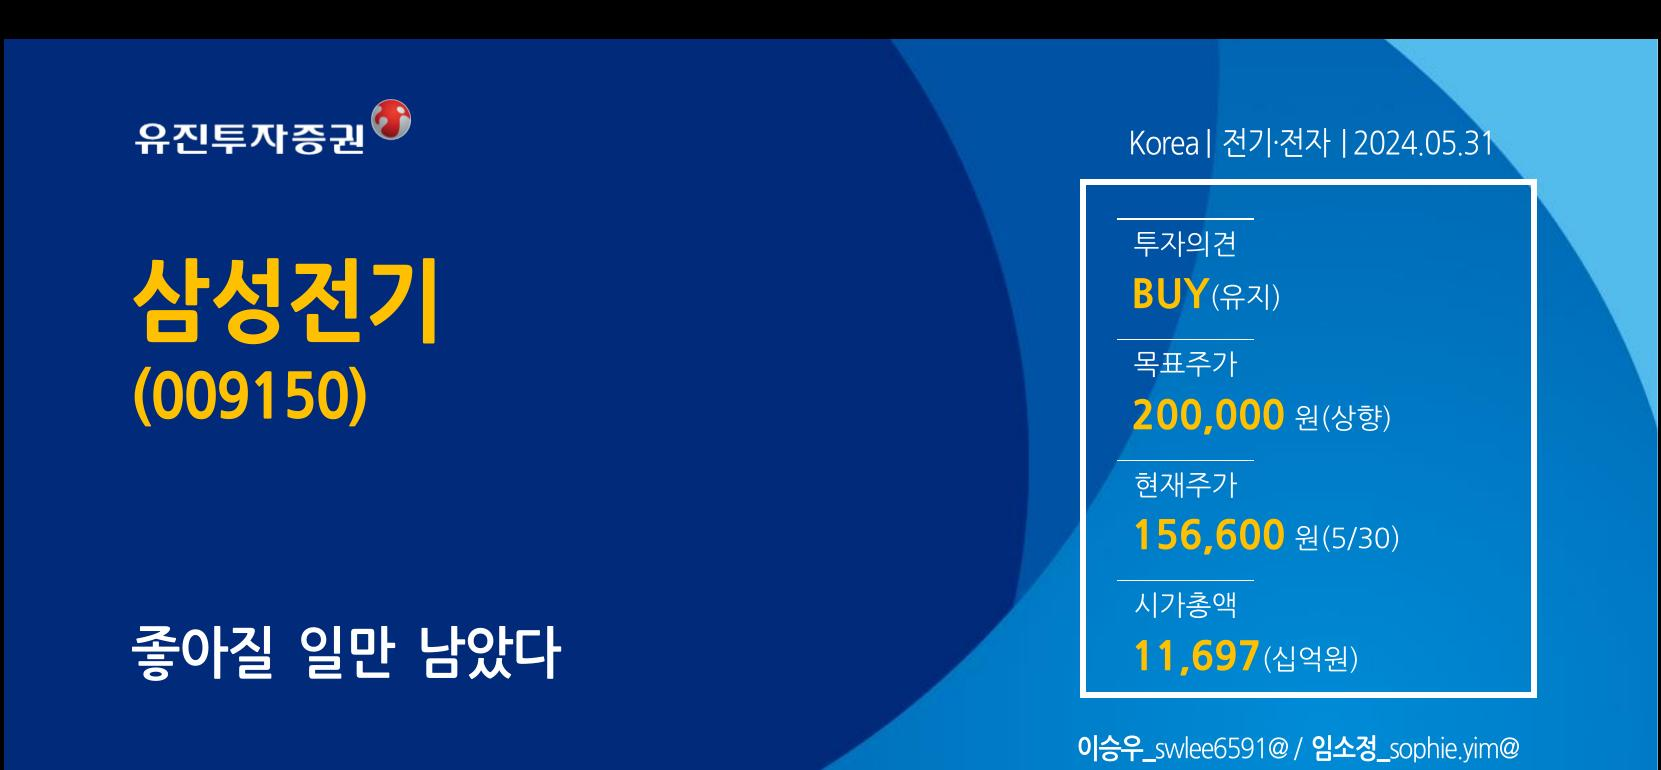

In [43]:
plt_img_base64(result['context']['images'][0])

---
## **[실습]**

- langchain_docling 라이브러리의 DoclingLoader 문서 로더를 활용하여 멀티모달 문서에 답변하는 RAG 시스템을 구축합니다.

In [44]:
# 여기에 코드를 작성하세요. 

In [45]:
import os
import base64
from typing import List, Dict
from io import BytesIO
import pandas as pd
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat
from docling.datamodel.document import TableItem
from docling.chunking import HybridChunker


class CustomPageImageLoader:
    """텍스트, 표(마크다운), 페이지 이미지를 통합 추출하는 로더"""

    def __init__(
        self, 
        file_paths: List[str],
        images_scale: float = 2.0,  # 144 DPI (2.0 * 72)
        enable_page_images: bool = True,
        enable_tables: bool = True,
        enable_text_chunking: bool = True,
        tokenizer: str = "BAAI/bge-m3",
        max_tokens: int = 8000
    ):
        """
        통합 문서 로더 초기화
        
        Args:
            file_paths: 처리할 PDF 파일 경로들
            images_scale: 이미지 해상도 스케일 (1.0=72DPI, 2.0=144DPI)
            enable_page_images: 페이지 이미지 생성 여부
            enable_tables: 테이블 추출 및 마크다운 변환 여부
            enable_text_chunking: 텍스트 청킹 여부
            tokenizer: 청킹에 사용할 토크나이저
            max_tokens: 청크당 최대 토큰 수
        """
        self.file_paths = file_paths
        self.images_scale = images_scale
        self.enable_page_images = enable_page_images
        self.enable_tables = enable_tables
        self.enable_text_chunking = enable_text_chunking
        self.tokenizer = tokenizer
        self.max_tokens = max_tokens
        self.all_documents = {}

        # 파이프라인 옵션 설정
        self.pipeline_options = PdfPipelineOptions()
        if self.enable_page_images:
            self.pipeline_options.images_scale = self.images_scale
            self.pipeline_options.generate_page_images = True
        
        if self.enable_tables:
            self.pipeline_options.do_table_structure = True
        
        # DocumentConverter 설정
        self.converter = DocumentConverter(
            format_options={
                InputFormat.PDF: PdfFormatOption(pipeline_options=self.pipeline_options)
            }
        )
        
        # Chunker 설정 (텍스트 청킹 활성화 시)
        if self.enable_text_chunking:
            self.chunker = HybridChunker(
                tokenizer=self.tokenizer,
                max_tokens=self.max_tokens,
                merge_peers=True
            )
    
    def _table_to_markdown(self, table: TableItem) -> str:
        """TableItem을 Markdown 형식으로 변환"""
        try:
            # export_to_dataframe 메서드 사용
            if hasattr(table, 'export_to_dataframe'):
                try:
                    df = table.export_to_dataframe()
                    if df is not None and not df.empty:
                        return df.to_markdown(index=False)
                except Exception as e:
                    print(f"    export_to_dataframe 실패: {e}")

            else:
                # export_to_markdown 메서드 사용
                markdown = table.export_to_markdown()
                if markdown:
                    return markdown
                else:
                    print("    export_to_markdown 결과가 비어있음")
                    
        except Exception as e:
            print(f"    테이블 변환 전체 오류: {e}")
            
        return ""
    
    def extract_document_content(self, file_path: str) -> Dict:
        """파일에서 텍스트, 표, 이미지를 모두 추출"""
        result = {
            'text_content': "",
            'text_chunks': [],
            'tables': {},
            'page_images': {},
            'metadata': {}
        }
        
        try:
            print(f"📄 처리 중: {os.path.basename(file_path)}")
            conv_res = self.converter.convert(file_path)
            doc = conv_res.document
            
            # 기본 메타데이터 수집
            result['metadata'] = {
                'file_path': file_path,
                'pages': len(doc.pages),
                'pictures': len(doc.pictures) if hasattr(doc, 'pictures') else 0,
                'tables': len(doc.tables) if hasattr(doc, 'tables') else 0
            }
            
            print(f"  📋 문서 정보: {result['metadata']['pages']}페이지, {result['metadata']['tables']}테이블, {result['metadata']['pictures']}그림")
            
            # 전체 텍스트 추출 (마크다운 형식)
            try:
                result['text_content'] = doc.export_to_markdown()
                print(f"  📝 텍스트 추출: {len(result['text_content'])} 문자")
            except Exception as e:
                print(f"  ⚠️ 텍스트 추출 실패: {e}")
            
            # 텍스트 청킹 (활성화된 경우)
            if self.enable_text_chunking and hasattr(self, 'chunker'):
                try:
                    chunks = list(self.chunker.chunk(doc))
                    result['text_chunks'] = []
                    
                    for idx, chunk in enumerate(chunks):
                        chunk_data = {
                            'index': idx,
                            'text': chunk.text,
                            'token_count': len(chunk.text.split()),  # 대략적인 토큰 수
                            'metadata': {}
                        }
                        
                        # 청크 메타데이터 추출
                        if hasattr(chunk, 'meta') and chunk.meta:
                            if hasattr(chunk.meta, 'page_range') and chunk.meta.page_range:
                                chunk_data['metadata']['pages'] = list(chunk.meta.page_range)
                        
                        result['text_chunks'].append(chunk_data)
                    
                    print(f"  📄 청킹 완료: {len(result['text_chunks'])}개 청크")
                except Exception as e:
                    print(f"  ⚠️ 청킹 실패: {e}")
            
            # 테이블 추출 및 마크다운 변환
            if self.enable_tables:
                try:
                    if hasattr(doc, 'tables') and doc.tables:
                        for idx, table in enumerate(doc.tables):
                            if isinstance(table, TableItem):
                                try:
                                    markdown_table = self._table_to_markdown(table)
                                    
                                    if markdown_table:
                                        table_key = f"table_{idx}"
                                        page_no = 'unknown'
                                        if hasattr(table, 'prov') and table.prov:
                                            page_no = table.prov[0].page_no if hasattr(table.prov[0], 'page_no') else 'unknown'
                                            table_key = f"table_{idx}_page{page_no}"
                                        
                                        result['tables'][table_key] = {
                                            'markdown': markdown_table,
                                            'page_no': page_no,
                                            'table_index': idx,
                                        }
                                        print(f"    ✅ 테이블 {idx} 변환 성공: {len(markdown_table)} 문자")
                                    else:
                                        print(f"    ⚠️ 테이블 {idx} 변환 결과가 비어있음")
                                        
                                except Exception as e:
                                    print(f"    ⚠️ 테이블 {idx} 변환 오류: {e}")
                    
                    print(f"  📊 테이블 추출: {len(result['tables'])}개")
                except Exception as e:
                    print(f"  ⚠️ 테이블 추출 실패: {e}")
            
            # 페이지 이미지 추출
            if self.enable_page_images:
                try:
                    for page_no, page in doc.pages.items():
                        try:
                            if hasattr(page, 'image') and page.image is not None:
                                # PIL 이미지를 base64로 변환
                                if hasattr(page.image, 'pil_image') and page.image.pil_image is not None:
                                    pil_img = page.image.pil_image
                                    
                                    # PNG 형식으로 base64 인코딩
                                    buffered = BytesIO()
                                    pil_img.save(buffered, format="PNG")
                                    img_bytes = buffered.getvalue()
                                    img_base64 = base64.b64encode(img_bytes).decode('utf-8')
                                    
                                    result['page_images'][f"page_{page_no}"] = {
                                        'base64': f"data:image/png;base64,{img_base64}",
                                        'width': pil_img.width,
                                        'height': pil_img.height,
                                        'page_no': page_no
                                    }
                                    print(f"    ✅ 페이지 {page_no}: {pil_img.width}x{pil_img.height} 이미지 추출 성공")
                                else:
                                    print(f"    ⚠️ 페이지 {page_no}: PIL 이미지 없음")
                            else:
                                print(f"    ⚠️ 페이지 {page_no}: 이미지 객체 없음")
                                
                        except Exception as e:
                            print(f"    ❌ 페이지 {page_no} 이미지 추출 실패: {e}")
                    
                    print(f"  🖼️ 페이지 이미지: {len(result['page_images'])}개")
                except Exception as e:
                    print(f"  ⚠️ 페이지 이미지 추출 실패: {e}")
                    
        except Exception as e:
            print(f"❌ 파일 처리 실패 {file_path}: {e}")
            
        return result
    
    def load_all_documents(self) -> Dict[str, Dict]:
        """모든 파일의 텍스트, 표, 이미지를 추출"""
        all_documents = {}
        
        print(f"🚀 문서 처리 시작")
        print(f"📋 설정: 이미지({self.enable_page_images}), 테이블({self.enable_tables}), 청킹({self.enable_text_chunking})")
        print("=" * 60)
        
        for file_path in self.file_paths:
            document_content = self.extract_document_content(file_path)
            all_documents[file_path] = document_content
        
        # 전체 요약
        total_files = len(all_documents)
        total_pages = sum(doc['metadata']['pages'] for doc in all_documents.values())
        total_tables = sum(len(doc['tables']) for doc in all_documents.values())
        total_images = sum(len(doc['page_images']) for doc in all_documents.values())
        total_chunks = sum(len(doc['text_chunks']) for doc in all_documents.values())
        
        print("=" * 60)
        print(f"🎉 전체 결과: {total_files}개 파일, {total_pages}페이지, {total_tables}테이블, {total_images}이미지, {total_chunks}청크")
        
        return all_documents
    
    def save_extracted_content(self, output_dir: str = "extracted_content") -> None:
        """추출된 콘텐츠를 파일로 저장"""
        import json
        
        os.makedirs(output_dir, exist_ok=True)

        if not self.all_documents:
            all_documents = self.load_all_documents()

        else:
            all_documents = self.all_documents

        for file_path, document_content in all_documents.items():
            file_name = os.path.splitext(os.path.basename(file_path))[0]
            
            # 전체 텍스트를 마크다운으로 저장
            if document_content['text_content']:
                md_path = os.path.join(output_dir, f"{file_name}_full_text.md")
                with open(md_path, 'w', encoding='utf-8') as f:
                    f.write(document_content['text_content'])
                print(f"💾 텍스트 저장: {md_path}")
            
            # 청크별 텍스트 저장
            if document_content['text_chunks']:
                chunks_dir = os.path.join(output_dir, f"{file_name}_chunks")
                os.makedirs(chunks_dir, exist_ok=True)
                
                for chunk in document_content['text_chunks']:
                    chunk_path = os.path.join(chunks_dir, f"chunk_{chunk['index']:03d}.md")
                    with open(chunk_path, 'w', encoding='utf-8') as f:
                        f.write(f"# Chunk {chunk['index']}\n\n")
                        f.write(f"**Token Count:** ~{chunk['token_count']}\n\n")
                        if chunk['metadata'].get('pages'):
                            f.write(f"**Pages:** {chunk['metadata']['pages']}\n\n")
                        f.write("---\n\n")
                        f.write(chunk['text'])
                
                print(f"💾 청크 저장: {chunks_dir} ({len(document_content['text_chunks'])}개)")
            
            # 테이블을 개별 마크다운으로 저장
            if document_content['tables']:
                tables_dir = os.path.join(output_dir, f"{file_name}_tables")
                os.makedirs(tables_dir, exist_ok=True)
                
                for table_key, table_info in document_content['tables'].items():
                    table_path = os.path.join(tables_dir, f"{table_key}.md")
                    with open(table_path, 'w', encoding='utf-8') as f:
                        f.write(f"# {table_key}\n\n")
                        f.write(f"**Page:** {table_info['page_no']}\n\n")
                        f.write("---\n\n")
                        f.write(table_info['markdown'])
                
                print(f"💾 테이블 저장: {tables_dir} ({len(document_content['tables'])}개)")
            
            # 페이지 이미지 저장
            if document_content['page_images']:
                images_dir = os.path.join(output_dir, f"{file_name}_images")
                os.makedirs(images_dir, exist_ok=True)
                
                for page_key, page_info in document_content['page_images'].items():
                    # base64 데이터를 디코딩하여 파일로 저장
                    base64_data = page_info['base64'].split(',')[1]
                    img_bytes = base64.b64decode(base64_data)
                    
                    img_path = os.path.join(images_dir, f"{page_key}.png")
                    with open(img_path, 'wb') as f:
                        f.write(img_bytes)
                
                print(f"💾 이미지 저장: {images_dir} ({len(document_content['page_images'])}개)")
                
            # 메타데이터를 JSON으로 저장
            metadata_path = os.path.join(output_dir, f"{file_name}_metadata.json")
            with open(metadata_path, 'w', encoding='utf-8') as f:
                # base64 이미지 데이터는 제외하고 메타데이터만 저장
                metadata = {
                    'file_info': document_content['metadata'],
                    'text_length': len(document_content['text_content']),
                    'chunk_count': len(document_content['text_chunks']),
                    'table_count': len(document_content['tables']),
                    'image_count': len(document_content['page_images']),
                    'tables_info': {k: {**v, 'markdown': None} for k, v in document_content['tables'].items()},
                    'images_info': {k: {**v, 'base64': None} for k, v in document_content['page_images'].items()}
                }
                json.dump(metadata, f, indent=2, ensure_ascii=False)
            
            print(f"💾 메타데이터 저장: {metadata_path}")

In [46]:
# 통합 로더 생성
loader = CustomPageImageLoader(
    file_paths=pdf_files,  # PDF 파일 경로 리스트
    images_scale=2.0,          # 144 DPI
    enable_page_images=True,   # 페이지 이미지 추출
    enable_tables=True,        # 테이블을 마크다운으로 변환
    enable_text_chunking=True, # 텍스트 청킹
    max_tokens=8000           # 청크당 최대 토큰
)

# 모든 콘텐츠 추출
all_documents = loader.load_all_documents()

print(f"📄 전체 문서 개수: {len(all_documents)}개")

2025-12-02 13:20:31,045 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-12-02 13:20:31,091 - INFO - Going to convert document batch...
2025-12-02 13:20:31,092 - INFO - Initializing pipeline for StandardPdfPipeline with options hash 03fa174da29dfa0da23f2895018fe1be
2025-12-02 13:20:31,129 - INFO - Loading plugin 'docling_defaults'
2025-12-02 13:20:31,132 - INFO - Registered picture descriptions: ['vlm', 'api']
2025-12-02 13:20:31,165 - INFO - Loading plugin 'docling_defaults'
2025-12-02 13:20:31,172 - INFO - Registered ocr engines: ['auto', 'easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']


🚀 문서 처리 시작
📋 설정: 이미지(True), 테이블(True), 청킹(True)
📄 처리 중: 20240524_company_234017000.pdf


2025-12-02 13:20:31,376 - INFO - Accelerator device: 'cpu'
[INFO] 2025-12-02 13:20:31,397 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2025-12-02 13:20:31,405 [RapidOCR] download_file.py:60: File exists and is valid: H:\miniconda3\envs\modu3\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2025-12-02 13:20:31,406 [RapidOCR] main.py:53: Using H:\miniconda3\envs\modu3\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2025-12-02 13:20:31,482 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2025-12-02 13:20:31,484 [RapidOCR] download_file.py:60: File exists and is valid: H:\miniconda3\envs\modu3\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2025-12-02 13:20:31,485 [RapidOCR] main.py:53: Using H:\miniconda3\envs\modu3\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2025-12-02 13:20:31,529 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2025-12-02 13:20:31

  📋 문서 정보: 8페이지, 5테이블, 5그림
  📝 텍스트 추출: 31554 문자
  📄 청킹 완료: 8개 청크


2025-12-02 13:21:26,871 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:21:26,877 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:21:26,880 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:21:26,894 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:21:26,896 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


...

    ✅ 테이블 0 변환 성공: 1296 문자
    ✅ 테이블 1 변환 성공: 8500 문자
    ✅ 테이블 2 변환 성공: 1265 문자
  📊 테이블 추출: 3개
    ✅ 페이지 1: 1191x1684 이미지 추출 성공
    ✅ 페이지 2: 1191x1684 이미지 추출 성공


2025-12-02 13:22:06,273 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-12-02 13:22:06,278 - INFO - Going to convert document batch...
2025-12-02 13:22:06,279 - INFO - Processing document 20240531_company_753270000.pdf


    ✅ 페이지 3: 1191x1684 이미지 추출 성공
  🖼️ 페이지 이미지: 3개
📄 처리 중: 20240531_company_753270000.pdf


2025-12-02 13:22:48,767 - INFO - Finished converting document 20240531_company_753270000.pdf in 42.50 sec.
2025-12-02 13:22:48,893 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:22:48,896 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:22:48,899 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:22:48,913 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:22:48,915 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


  📋 문서 정보: 3페이지, 5테이블, 3그림
  📝 텍스트 추출: 15519 문자
  📄 청킹 완료: 4개 청크
    ✅ 테이블 0 변환 성공: 1556 문자
    ✅ 테이블 1 변환 성공: 781 문자
    ✅ 테이블 2 변환 성공: 8500 문자
    ✅ 테이블 3 변환 성공: 1265 문자
    ✅ 테이블 4 변환 성공: 2280 문자
  📊 테이블 추출: 5개
    ✅ 페이지 1: 1191x1684 이미지 추출 성공
    ✅ 페이지 2: 1191x1684 이미지 추출 성공
    ✅ 페이지 3: 1191x1684 이미지 추출 성공
  🖼️ 페이지 이미지: 3개
🎉 전체 결과: 3개 파일, 14페이지, 13테이블, 14이미지, 16청크
📄 전체 문서 개수: 3개


In [47]:
# 추출된 콘텐츠를 파일로 저장
output_dir = "extracted_content"
os.makedirs(output_dir, exist_ok=True)

loader.save_extracted_content(output_dir=output_dir)

2025-12-02 13:22:49,134 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-12-02 13:22:49,140 - INFO - Going to convert document batch...
2025-12-02 13:22:49,141 - INFO - Processing document 20240524_company_234017000.pdf


🚀 문서 처리 시작
📋 설정: 이미지(True), 테이블(True), 청킹(True)
📄 처리 중: 20240524_company_234017000.pdf


2025-12-02 13:23:40,879 - INFO - Finished converting document 20240524_company_234017000.pdf in 51.75 sec.


  📋 문서 정보: 8페이지, 5테이블, 5그림
  📝 텍스트 추출: 31554 문자
  📄 청킹 완료: 8개 청크


2025-12-02 13:23:41,105 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:23:41,111 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:23:41,115 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:23:41,129 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:23:41,131 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


...

    ✅ 테이블 0 변환 성공: 1296 문자
    ✅ 테이블 1 변환 성공: 8500 문자
    ✅ 테이블 2 변환 성공: 1265 문자
  📊 테이블 추출: 3개
    ✅ 페이지 1: 1191x1684 이미지 추출 성공
    ✅ 페이지 2: 1191x1684 이미지 추출 성공


2025-12-02 13:24:18,868 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-12-02 13:24:18,873 - INFO - Going to convert document batch...
2025-12-02 13:24:18,874 - INFO - Processing document 20240531_company_753270000.pdf


    ✅ 페이지 3: 1191x1684 이미지 추출 성공
  🖼️ 페이지 이미지: 3개
📄 처리 중: 20240531_company_753270000.pdf


2025-12-02 13:25:00,631 - INFO - Finished converting document 20240531_company_753270000.pdf in 41.77 sec.
2025-12-02 13:25:00,754 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:25:00,757 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:25:00,759 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:25:00,773 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
2025-12-02 13:25:00,775 - WARNING - Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


  📋 문서 정보: 3페이지, 5테이블, 3그림
  📝 텍스트 추출: 15519 문자
  📄 청킹 완료: 4개 청크
    ✅ 테이블 0 변환 성공: 1556 문자
    ✅ 테이블 1 변환 성공: 781 문자
    ✅ 테이블 2 변환 성공: 8500 문자
    ✅ 테이블 3 변환 성공: 1265 문자
    ✅ 테이블 4 변환 성공: 2280 문자
  📊 테이블 추출: 5개
    ✅ 페이지 1: 1191x1684 이미지 추출 성공
    ✅ 페이지 2: 1191x1684 이미지 추출 성공
    ✅ 페이지 3: 1191x1684 이미지 추출 성공
  🖼️ 페이지 이미지: 3개
🎉 전체 결과: 3개 파일, 14페이지, 13테이블, 14이미지, 16청크
💾 텍스트 저장: extracted_content\20240524_company_234017000_full_text.md
💾 청크 저장: extracted_content\20240524_company_234017000_chunks (8개)
💾 테이블 저장: extracted_content\20240524_company_234017000_tables (5개)
💾 이미지 저장: extracted_content\20240524_company_234017000_images (8개)
💾 메타데이터 저장: extracted_content\20240524_company_234017000_metadata.json
💾 텍스트 저장: extracted_content\20240531_company_652771000_full_text.md
💾 청크 저장: extracted_content\20240531_company_652771000_chunks (4개)
💾 테이블 저장: extracted_content\20240531_company_652771000_tables (3개)
💾 이미지 저장: extracted_content\20240531_company_652771000_images (3개)
💾 메타데이터 저장: extracted

In [48]:
# Text 청크 객체 확인
text_chunks = all_documents[pdf_files[0]]['text_chunks']
print(f"📝 첫 번째 PDF의 텍스트 청크 개수: {len(text_chunks)}")

# 첫 번째 청크 내용 확인
if text_chunks:
    first_chunk = text_chunks[0]
    print(f"첫 번째 청크 내용 (토큰 수: {first_chunk['token_count']}):")
    print(first_chunk['text'][:200] + "...")  # 처음 200자만 출력

📝 첫 번째 PDF의 텍스트 청크 개수: 8
첫 번째 청크 내용 (토큰 수: 946):
- :  짐펜트라, 시간의 문제
투자의견
BUY (유지)
목표주가
250,000 원(유지)
현재주가
183,500 원(05/23)
시가총액
39,818 (십억원)
제약/바이오  권해순_ 02)368-6181_ hskwon@eugenefn.com
-  투자의견 BUY 및 목표주가 25만원 유지, 적극적으로 매수해야 할 때라고 판단함
-  밸류체인 일원화와...


In [49]:
# Table 객체 확인
tables = all_documents[pdf_files[0]]['tables']
print(f"📊 첫 번째 PDF의 테이블 개수: {len(tables)}")

# 첫 번째 테이블 내용 확인
if tables:
    first_table = tables[list(tables.keys())[0]]
    print(f"첫 번째 테이블 내용 (페이지: {first_table['page_no']}):")
    print(first_table['markdown'][:200] + "...")  # 처음 200자만 출력

📊 첫 번째 PDF의 테이블 개수: 5
첫 번째 테이블 내용 (페이지: 1):
| 0                                                   | 1                                                   | 2                                                   | 3                                   ...


🖼️ 첫 번째 PDF의 페이지 이미지 개수: 8



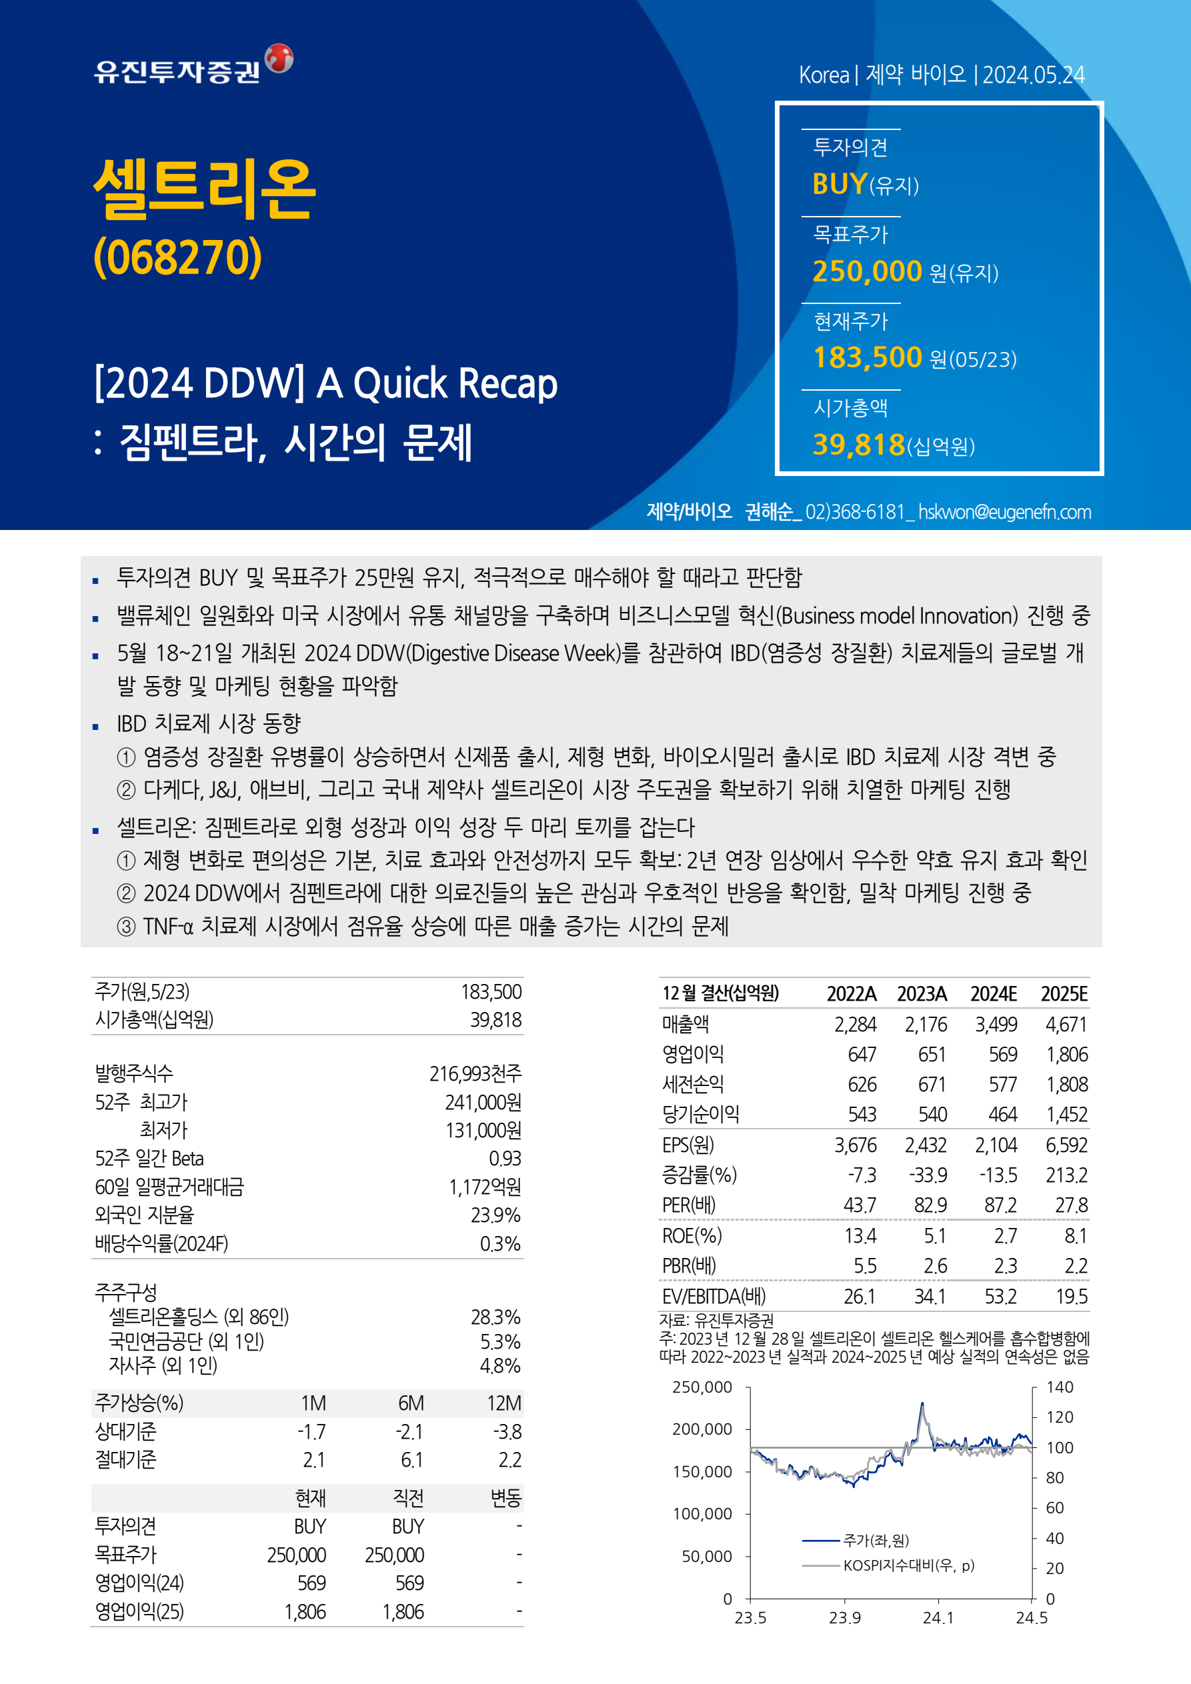

In [50]:
# Image 객체 확인
page_images = all_documents[pdf_files[0]]['page_images']
print(f"🖼️ 첫 번째 PDF의 페이지 이미지 개수: {len(page_images)}")

# 첫 번째 페이지 이미지 내용 확인
if page_images:
    first_image = page_images['page_1']  # 첫 번째 페이지 이미지
    plt_img_base64(first_image['base64'].replace("data:image/png;base64,", ""))  # 이미지 표시

---
## **[실습 프로젝트]**

- 옵션 2, 옵션 3에서 적용한 멀티모달 RAG 시스템을 활용하여 증권사 분석보고서에 대한 질문에 답변하는 시스템을 구축합니다.
- 멀티모달 컨텍스트를 구성하는 다양한 방법과 차이점에 대해 비교합니다.

In [53]:
"""
[실습 프로젝트] CustomPageImageLoader를 활용한 멀티모달 RAG 시스템 구축
- Docling으로 추출한 텍스트, 테이블, 이미지를 활용
- 옵션 3 방식: 텍스트 임베딩 + 원본 이미지 참조
"""

import uuid
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser

print("=" * 80)
print("📚 Docling 기반 멀티모달 RAG 시스템 구축")
print("=" * 80)

# ============================================================================
# 1. 벡터스토어 및 검색기 설정
# ============================================================================

# 벡터 저장소 생성
vectorstore_docling = Chroma(
    collection_name="docling_multimodal_rag",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./docling_chroma_db",
)

# 부모 문서 저장소
store_docling = InMemoryStore()
id_key = "doc_id"

# 검색기 생성
retriever_docling = MultiVectorRetriever(
    vectorstore=vectorstore_docling,
    docstore=store_docling,
    id_key=id_key,
)

print("\n✅ 벡터스토어 및 검색기 초기화 완료")

# ============================================================================
# 2. 텍스트 청크 추가
# ============================================================================

print("\n" + "=" * 80)
print("📝 텍스트 청크 벡터스토어에 추가")
print("=" * 80)

# 모든 PDF의 텍스트 청크 수집
all_text_chunks = []
for pdf_path, doc_content in all_documents.items():
    for chunk in doc_content['text_chunks']:
        # 메타데이터에서 리스트를 문자열로 변환 (Chroma 호환성)
        pages = chunk['metadata'].get('pages', [])
        pages_str = ','.join(map(str, pages)) if pages else ''
        
        all_text_chunks.append({
            'text': chunk['text'],
            'metadata': {
                'file': pdf_path,
                'pages': pages_str,  # 리스트 대신 문자열
                'token_count': chunk['token_count']
            }
        })

print(f"  총 텍스트 청크: {len(all_text_chunks)}개")

# 텍스트 청크 ID 생성
text_chunk_ids = [str(uuid.uuid4()) for _ in all_text_chunks]

# 요약 문서 생성 (청크 텍스트를 그대로 사용)
summary_text_docs = [
    Document(
        page_content=chunk['text'][:500],  # 처음 500자를 요약으로 사용
        metadata={id_key: text_chunk_ids[i], "source": "text", **chunk['metadata']}
    )
    for i, chunk in enumerate(all_text_chunks)
]

# 원본 텍스트 문서 생성
original_text_docs = [
    Document(
        page_content=chunk['text'],
        metadata={id_key: text_chunk_ids[i], "source": "text", **chunk['metadata']}
    )
    for i, chunk in enumerate(all_text_chunks)
]

# 벡터스토어에 추가
retriever_docling.vectorstore.add_documents(summary_text_docs)
retriever_docling.docstore.mset(list(zip(text_chunk_ids, original_text_docs)))

print(f"✅ {len(summary_text_docs)}개 텍스트 청크 추가 완료")

# ============================================================================
# 3. 테이블 추가
# ============================================================================

print("\n" + "=" * 80)
print("📊 테이블 벡터스토어에 추가")
print("=" * 80)

# 모든 PDF의 테이블 수집
all_tables = []
for pdf_path, doc_content in all_documents.items():
    for table_key, table_info in doc_content['tables'].items():
        all_tables.append({
            'markdown': table_info['markdown'],
            'metadata': {
                'file': pdf_path,
                'page_no': str(table_info['page_no']),  # 문자열로 변환
                'table_index': table_info['table_index']
            }
        })

print(f"  총 테이블: {len(all_tables)}개")

# 테이블 ID 생성
table_ids = [str(uuid.uuid4()) for _ in all_tables]

# 요약 문서 생성 (테이블 마크다운의 처음 부분)
summary_table_docs = [
    Document(
        page_content=f"테이블 (페이지 {table['metadata']['page_no']}): {table['markdown'][:300]}",
        metadata={id_key: table_ids[i], "source": "table", **table['metadata']}
    )
    for i, table in enumerate(all_tables)
]

# 원본 테이블 문서 생성
original_table_docs = [
    Document(
        page_content=table['markdown'],
        metadata={id_key: table_ids[i], "source": "table", **table['metadata']}
    )
    for i, table in enumerate(all_tables)
]

# 벡터스토어에 추가
retriever_docling.vectorstore.add_documents(summary_table_docs)
retriever_docling.docstore.mset(list(zip(table_ids, original_table_docs)))

print(f"✅ {len(summary_table_docs)}개 테이블 추가 완료")

# ============================================================================
# 4. 페이지 이미지 추가
# ============================================================================

print("\n" + "=" * 80)
print("🖼️ 페이지 이미지 벡터스토어에 추가")
print("=" * 80)

# 모든 PDF의 페이지 이미지 수집
all_page_images = []
for pdf_path, doc_content in all_documents.items():
    for page_key, page_info in doc_content['page_images'].items():
        # base64에서 data URI 제거
        base64_data = page_info['base64'].replace("data:image/png;base64,", "")
        
        all_page_images.append({
            'base64': base64_data,
            'metadata': {
                'file': pdf_path,
                'page_no': page_info['page_no'],
                'width': page_info['width'],
                'height': page_info['height']
            }
        })

print(f"  총 페이지 이미지: {len(all_page_images)}개")

# 이미지 ID 생성
image_ids = [str(uuid.uuid4()) for _ in all_page_images]

# 요약 문서 생성 (이미지 메타정보를 텍스트로)
summary_image_docs = [
    Document(
        page_content=f"페이지 {img['metadata']['page_no']} 이미지 ({img['metadata']['width']}x{img['metadata']['height']})",
        metadata={id_key: image_ids[i], "source": "image", **img['metadata']}
    )
    for i, img in enumerate(all_page_images)
]

# 원본 이미지 문서 생성 (base64 데이터)
original_image_docs = [
    Document(
        page_content=img['base64'],
        metadata={id_key: image_ids[i], "source": "image", **img['metadata']}
    )
    for i, img in enumerate(all_page_images)
]

# 벡터스토어에 추가
retriever_docling.vectorstore.add_documents(summary_image_docs)
retriever_docling.docstore.mset(list(zip(image_ids, original_image_docs)))

print(f"✅ {len(summary_image_docs)}개 페이지 이미지 추가 완료")

# ============================================================================
# 5. RAG 체인 구성
# ============================================================================

print("\n" + "=" * 80)
print("🔗 RAG 체인 구성")
print("=" * 80)

def process_docling_prompt(kwargs):
    """Docling으로 추출한 문서를 기반으로 프롬프트 구성"""
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]
    
    print(f"\n검색된 문서:")
    print(f"  - 텍스트: {len(docs_by_type['texts'])}개")
    print(f"  - 이미지: {len(docs_by_type['images'])}개")
    print("-" * 80)
    
    # 텍스트 문맥 구성
    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        context_text = "\n\n".join(docs_by_type["texts"])
    
    # 프롬프트 템플릿
    prompt_template = f"""
    Based on the provided context, answer the question about financial analyst reports.
    The context includes text from documents, tables, and page images.
    
    When presenting numerical data, cite specific evidence from the context.
    
    [Context]
    {context_text}
    
    [Question]
    {user_question}
    
    [Answer (in 한국어)]
    """
    
    # 프롬프트 콘텐츠 초기화
    prompt_content = [{"type": "text", "text": prompt_template}]
    
    # 이미지 추가
    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            })
    
    return ChatPromptTemplate.from_messages([HumanMessage(content=prompt_content)])


# RAG 체인 생성
rag_chain_docling = (
    {
        "context": retriever_docling | RunnableLambda(split_image_text_types),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(process_docling_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

print("✅ RAG 체인 구성 완료")

# ============================================================================
# 6. 테스트 질문
# ============================================================================

print("\n" + "=" * 80)
print("💬 테스트 질문 실행")
print("=" * 80)

test_questions = [
    "삼성전기의 2024년 영업이익 전망은?",
    "셀트리온의 주요 투자 포인트는 무엇인가요?",
    "2024년 실적 전망을 보여주는 표는?",
]

for i, question in enumerate(test_questions, 1):
    print(f"\n[질문 {i}] {question}")
    print("-" * 80)
    
    try:
        answer = rag_chain_docling.invoke(question)
        print(f"[답변]\n{answer}")
    except Exception as e:
        print(f"❌ 오류 발생: {e}")
    
    print("=" * 80)

# ============================================================================
# 7. 옵션 비교 정리
# ============================================================================

print("\n" + "=" * 80)
print("📊 멀티모달 RAG 옵션 비교")
print("=" * 80)

comparison = """
┌─────────┬──────────────────┬────────────────┬──────────────────┐
│  옵션   │   임베딩 방식    │  벡터 DB 저장  │   이미지 활용    │
├─────────┼──────────────────┼────────────────┼──────────────────┤
│ 옵션 1  │ 멀티모달 (CLIP)  │ 이미지 + 텍스트│ 직접 (base64)    │
│         │                  │ 임베딩         │                  │
├─────────┼──────────────────┼────────────────┼──────────────────┤
│ 옵션 2  │ 텍스트 (OpenAI)  │ 텍스트 요약만  │ 요약으로 간접    │
│         │                  │                │                  │
├─────────┼──────────────────┼────────────────┼──────────────────┤
│ 옵션 3  │ 텍스트 (OpenAI)  │ 텍스트 요약 +  │ 원본 이미지 참조 │
│ (구현)  │                  │ 이미지 참조    │                  │
└─────────┴──────────────────┴────────────────┴──────────────────┘

**장단점 비교:**

옵션 1 (멀티모달 임베딩):
  ✅ 최고 이미지 검색 정확도
  ✅ 이미지-텍스트 통합 검색
  ❌ 높은 비용 (CLIP 임베딩)
  ❌ base64 오버헤드

옵션 2 (텍스트 요약만):
  ✅ 비용 효율적
  ✅ 기존 RAG 인프라 활용
  ❌ 이미지 정보 손실
  ❌ 답변 품질 제한적

옵션 3 (본 구현):
  ✅ 옵션 1과 2의 균형
  ✅ 이미지 정보 손실 최소화
  ✅ 비용 대비 좋은 성능
  ❌ 이미지 참조 관리 필요
"""

print(comparison)

print("\n" + "=" * 80)
print("✅ 실습 프로젝트 완료!")
print("=" * 80)

📚 Docling 기반 멀티모달 RAG 시스템 구축

✅ 벡터스토어 및 검색기 초기화 완료

📝 텍스트 청크 벡터스토어에 추가
  총 텍스트 청크: 16개
✅ 16개 텍스트 청크 추가 완료

📊 테이블 벡터스토어에 추가
  총 테이블: 13개
✅ 13개 테이블 추가 완료

🖼️ 페이지 이미지 벡터스토어에 추가
  총 페이지 이미지: 14개
✅ 14개 페이지 이미지 추가 완료

🔗 RAG 체인 구성
✅ RAG 체인 구성 완료

💬 테스트 질문 실행

[질문 1] 삼성전기의 2024년 영업이익 전망은?
--------------------------------------------------------------------------------

검색된 문서:
  - 텍스트: 4개
  - 이미지: 0개
--------------------------------------------------------------------------------
[답변]
삼성전기의 2024년 영업이익 전망은 8,779억원으로 예상됩니다.

[질문 2] 셀트리온의 주요 투자 포인트는 무엇인가요?
--------------------------------------------------------------------------------

검색된 문서:
  - 텍스트: 4개
  - 이미지: 0개
--------------------------------------------------------------------------------
[답변]
셀트리온의 주요 투자 포인트는 다음과 같습니다:

1. **목표주가 및 투자의견**: 셀트리온에 대한 투자의견은 "BUY"로 유지되며, 목표주가는 25만원으로 설정되었습니다. 이는 합병 이후 원가율이 정상화되는 2025년 예상 순이익 1.45조원을 현가화하여 Target P/E 40배를 적용한 결과입니다.

2. **영업이익 및 매출 성장**: 2024년과 2025년의 예상 영업이익은 각각 약 5,700억원과 1.8조원으로 증가할 것으로 보